<a href="https://colab.research.google.com/github/abhioverdue/Normalization-Across-Datasets-A-Study/blob/main/CIFAR_10_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Normalization Study - CIFAR 10

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
# Seed

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)

In [ ]:
# Dataset

def get_dataloaders(batch_size):

    transform=transforms.ToTensor()

    train_dataset=torchvision.datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )

    test_dataset=torchvision.datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )

    train_loader=torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader=torch.utils.data.DataLoader(
        test_dataset,
        batch_size=batch_size
    )

    return train_loader,test_loader

In [ ]:
# Model
class CNN(nn.Module):

    def __init__(self,norm="batch"):
        super().__init__()

        self.conv1=nn.Conv2d(3,32,3,padding=1)
        self.conv2=nn.Conv2d(32,64,3,padding=1)

        if norm=="batch":
            self.norm1=nn.BatchNorm2d(32)
            self.norm2=nn.BatchNorm2d(64)

        elif norm=="layer":
            self.norm1=nn.GroupNorm(1,32)
            self.norm2=nn.GroupNorm(1,64)

        elif norm=="group":
            self.norm1=nn.GroupNorm(8,32)
            self.norm2=nn.GroupNorm(8,64)

        else:
            self.norm1=nn.Identity()
            self.norm2=nn.Identity()

        self.pool=nn.MaxPool2d(2)
        self.fc=nn.Linear(64*16*16,10)

    def forward(self,x):
        x=torch.relu(self.norm1(self.conv1(x)))
        x=torch.relu(self.norm2(self.conv2(x)))
        x=self.pool(x)
        x=x.view(x.size(0),-1)
        x=self.fc(x)

        return x

In [ ]:
# Evaluate
def evaluate(model,loader):

    model.eval()
    correct=0
    total=0

    with torch.no_grad():
        for images,labels in loader:
            images=images.to(device)
            labels=labels.to(device)
            outputs=model(images)
            _,pred=torch.max(outputs,1)
            total+=labels.size(0)
            correct+=(pred==labels).sum().item()

    return correct/total


In [ ]:
# Train

def train_model(model,train_loader,test_loader,epochs=10):

    model.to(device)
    optimizer=optim.Adam(model.parameters(),lr=0.001)
    criterion=nn.CrossEntropyLoss()

    grad_norms=[]
    losses=[]

    for epoch in range(epochs):

        model.train()
        loss_epoch=0
        grad_epoch=0

        for images,labels in train_loader:
            images=images.to(device)
            labels=labels.to(device)
            optimizer.zero_grad()
            outputs=model(images)
            loss=criterion(outputs,labels)
            loss.backward()
            grad_norm=0
            for p in model.parameters():
                if p.grad is not None:
                    grad_norm+=p.grad.data.norm(2).item()
            grad_epoch+=grad_norm
            optimizer.step()
            loss_epoch+=loss.item()
        losses.append(loss_epoch/len(train_loader))
        grad_norms.append(grad_epoch/len(train_loader))
    acc=evaluate(model,test_loader)

    return losses,grad_norms,acc


In [ ]:
import os
import pandas as pd

progress_file = "cifar_progress.csv"

if os.path.exists(progress_file):
    df_progress = pd.read_csv(progress_file)
    results = df_progress.to_dict("records")
    print("Loaded previous progress:", len(results), "runs")
else:
    results = []

Running: batch 64 0


100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


Running: batch 64 1
Running: batch 8 0
Running: batch 8 1
Running: layer 64 0
Running: layer 64 1
Running: layer 8 0
Running: layer 8 1
Running: group 64 0
Running: group 64 1
Running: group 8 0
Running: group 8 1
Running: none 64 0
Running: none 64 1
Running: none 8 0
Running: none 8 1
     norm  batch_size  seed  accuracy  grad_norm
0   batch          64     0    0.6687   9.477537
1   batch          64     1    0.6791   9.554769
2   batch           8     0    0.6714  13.051570
3   batch           8     1    0.6607  13.514675
4   layer          64     0    0.6774  13.914863
5   layer          64     1    0.6626  13.404820
6   layer           8     0    0.6640  15.087011
7   layer           8     1    0.6583  15.158747
8   group          64     0    0.6767  14.127083
9   group          64     1    0.6771  12.893495
10  group           8     0    0.6591  14.883925
11  group           8     1    0.6671  14.539433
12   none          64     0    0.6631   7.685690
13   none          64     

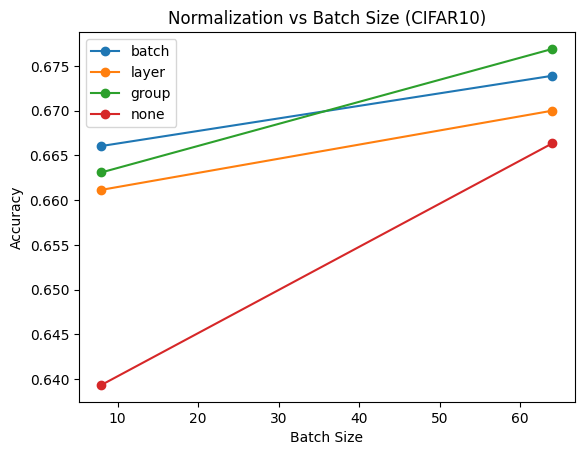

In [ ]:
# Experiment

batch_sizes=[64,8]
norms=["batch","layer","group","none"]
seeds=[0,1]

import os
progress_file="cifar_progress.csv"

# Load previous progress
if os.path.exists(progress_file):
    df=pd.read_csv(progress_file)
    results=df.to_dict("records")
else:
    results=[]

for norm in norms:
    for bs in batch_sizes:
        for seed in seeds:
            already_done = any(
                r["norm"] == norm and
                r["batch_size"] == bs and
                r["seed"] == seed
                for r in results
            )

            if already_done:
                print("Skipping:",norm,bs,seed)
                continue
            print("Running:",norm,bs,seed)
            set_seed(seed)
            train_loader,test_loader=get_dataloaders(bs)
            model=CNN(norm)
            loss,grad,acc=train_model(model,train_loader,test_loader)
            results.append({
                "norm":norm,
                "batch_size":bs,
                "seed":seed,
                "accuracy":acc,
                "grad_norm":np.mean(grad)
            })
            pd.DataFrame(results).to_csv(progress_file,index=False)

df=pd.DataFrame(results)
print(df)
df.to_csv("cifar_full_results.csv",index=False)
plt.figure()
for norm in norms:
    subset=df[df.norm==norm]
    mean_acc=subset.groupby("batch_size").accuracy.mean()
    plt.plot(mean_acc.index,mean_acc.values,marker="o",label=norm)

plt.xlabel("Batch Size")
plt.ylabel("Accuracy")
plt.title("Normalization vs Batch Size (CIFAR10)")
plt.legend()
plt.show()
